In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from db import get_engine
from geo_features import haversine_km

plt.rcParams["figure.figsize"] = (10, 6)


## 1. Load order-level data

In [2]:
engine = get_engine()
query_path = PROJECT_ROOT / "queries" / "customer_segmentation_features.sql"
orders = pd.read_sql(
    query_path.read_text(),
    engine,
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date"],
)
print(orders.shape)
orders.head()


(99441, 12)


,customer_unique_id,order_id,order_purchase_timestamp,order_delivered_customer_date,freight_value,payment_value,payment_installments,review_score,customer_lat,customer_lng,seller_lat,seller_lng
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,8.72,38.71,1.0,4.0,-23.576983,-46.587161,-23.680729,-46.444238
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,22.76,141.46,1.0,4.0,-12.177924,-44.660711,-19.807681,-43.980427
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,19.22,179.12,3.0,5.0,-16.745150,-48.514783,-21.363502,-48.229601
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,27.20,72.20,1.0,5.0,-5.774190,-35.271143,-19.837682,-43.924053
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,8.72,28.62,1.0,5.0,-23.676370,-46.514627,-23.543395,-46.262086


## 2. Build customer-level features

In [3]:
orders["distance_km"] = haversine_km(
    orders["customer_lat"], orders["customer_lng"], orders["seller_lat"], orders["seller_lng"]
)
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

snapshot_date = orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

customers = orders.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda s: (snapshot_date - s.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum"),
    avg_review_score=("review_score", "mean"),
    avg_delivery_time_days=("delivery_time_days", "mean"),
    avg_freight_value=("freight_value", "mean"),
    avg_payment_installments=("payment_installments", "mean"),
    avg_distance_km=("distance_km", "mean"),
).reset_index()

print(customers.shape)
customers.head()


(96096, 9)


,customer_unique_id,recency_days,frequency,monetary,avg_review_score,avg_delivery_time_days,avg_freight_value,avg_payment_installments,avg_distance_km
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,5.0,6.0,12.00,8.0,110.568636
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4.0,3.0,8.29,1.0,22.168333
2,0000f46a3911fa3c0805444483337064,586,1,86.22,3.0,25.0,17.22,8.0,516.938836
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,4.0,20.0,17.63,4.0,2481.287188
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,5.0,13.0,16.89,6.0,154.507887


In [4]:
FEATURE_COLS = [
    "recency_days", "frequency", "monetary", "avg_review_score",
    "avg_delivery_time_days", "avg_freight_value", "avg_payment_installments", "avg_distance_km",
]

before = len(customers)
customers = customers.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f"Dropped {before - len(customers)} customers with missing features; {len(customers)} remain")


Dropped 3799 customers with missing features; 92297 remain


## 3. Box plot before outlier removal

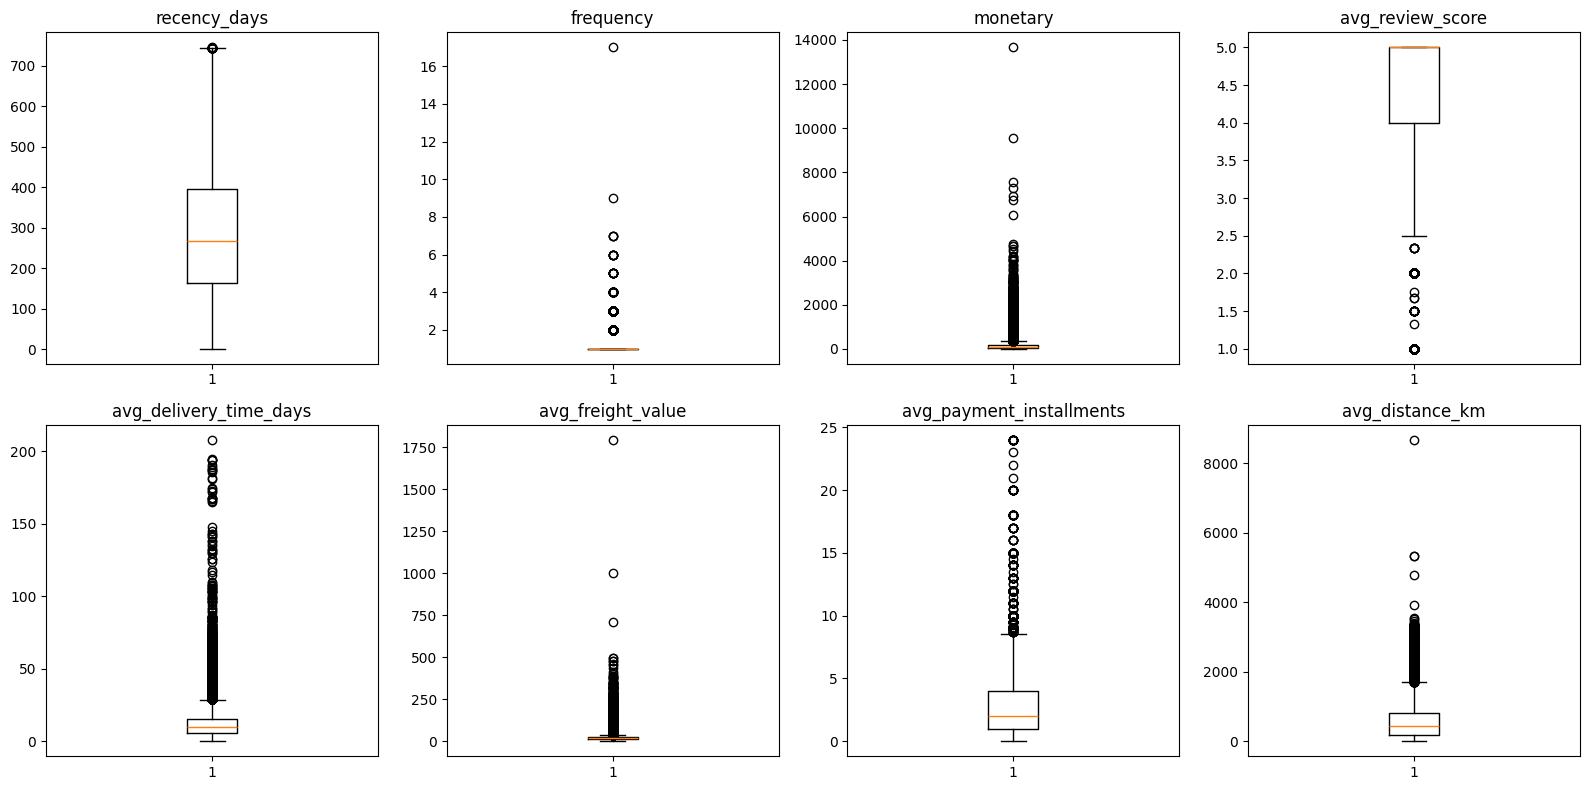

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.boxplot(customers[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 4. Remove outliers (IQR)

In [6]:
# frequency and avg_review_score are excluded from the outlier mask: their IQR
# bounds are degenerate here (most customers order exactly once, most reviews
# are 4-5 stars), so IQR would flag almost every repeat buyer / low scorer.
IQR_COLS = [c for c in FEATURE_COLS if c not in ("frequency", "avg_review_score")]

mask = pd.Series(False, index=customers.index)
for col in IQR_COLS:
    q1, q3 = customers[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask |= (customers[col] < lower) | (customers[col] > upper)

print(f"Flagged {mask.sum()} outlier rows ({mask.mean():.1%})")
customers_clean = customers.loc[~mask].reset_index(drop=True)
print(f"{len(customers_clean)} customers remain")


Flagged 23495 outlier rows (25.5%)
68802 customers remain


## 5. Box plot after outlier removal

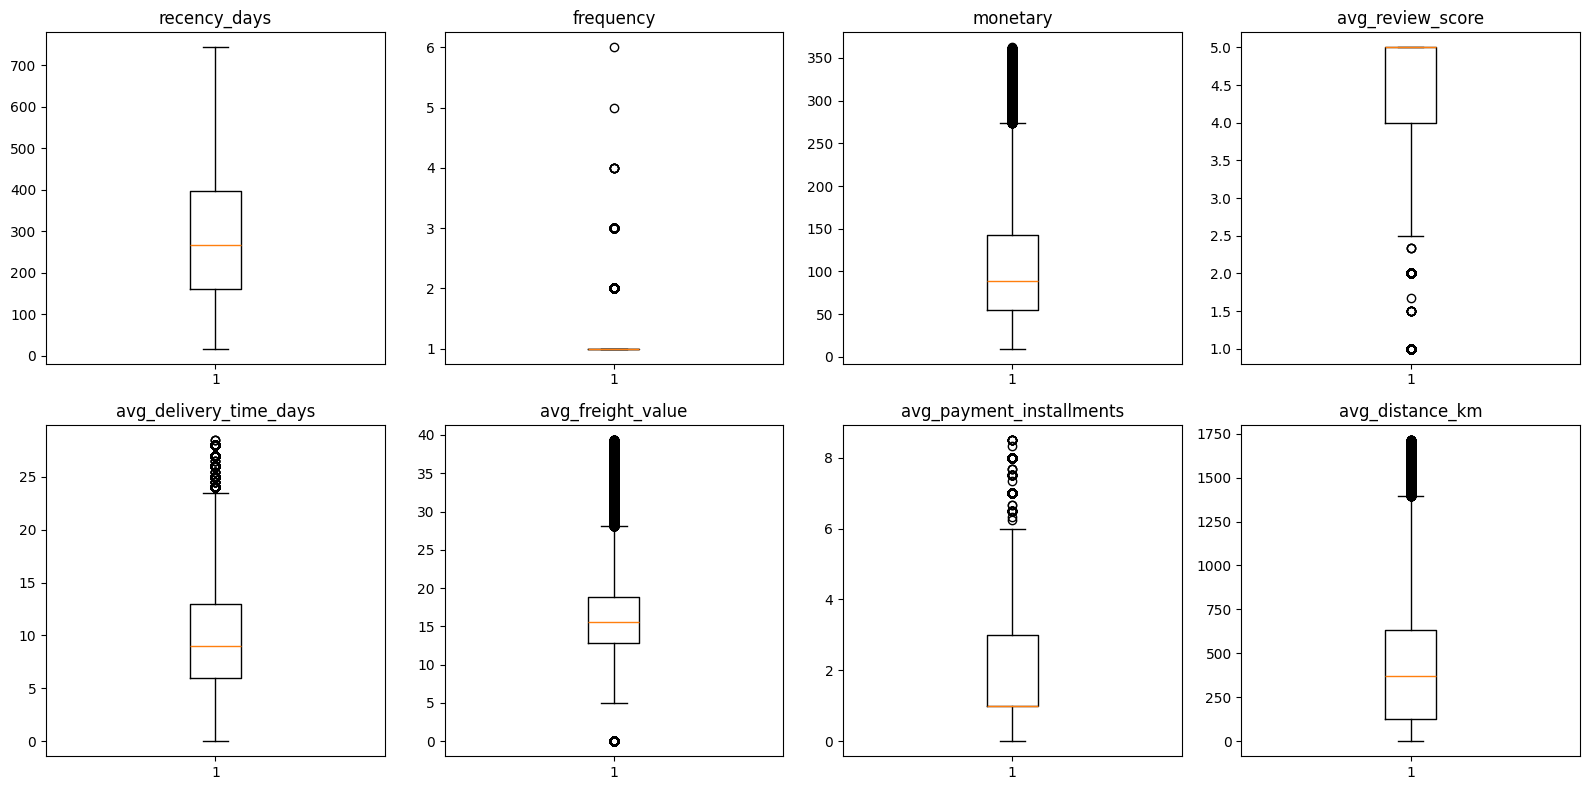

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.boxplot(customers_clean[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 6. Standardize features

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customers_clean[FEATURE_COLS])
print("mean:", X_scaled.mean(axis=0).round(2))
print("std:", X_scaled.std(axis=0).round(2))


mean: [ 0.  0. -0. -0. -0.  0.  0. -0.]
std: [1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Elbow method

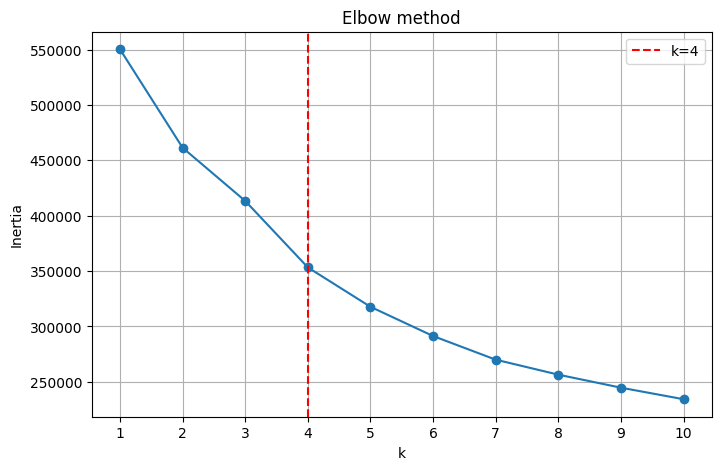

In [9]:
k_range = range(1, 11)
inertias = []
for k in k_range:
    # init="random" + n_init=20: 20 independent random centroid restarts,
    # keeping the lowest-inertia run
    km = KMeans(n_clusters=k, init="random", n_init=20, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.axvline(4, color="red", linestyle="--", label="k=4")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.xticks(list(k_range))
plt.legend()
plt.grid(True)
plt.show()


## 8. Final clustering (k=4)

In [10]:
kmeans = KMeans(n_clusters=4, init="random", n_init=20, random_state=42)
customers_clean["cluster"] = kmeans.fit_predict(X_scaled)
customers_clean["cluster"].value_counts().sort_index()


cluster
0    30769
1    13832
2     1964
3    22237
Name: count, dtype: int64

## 9. Cluster visual (PCA)

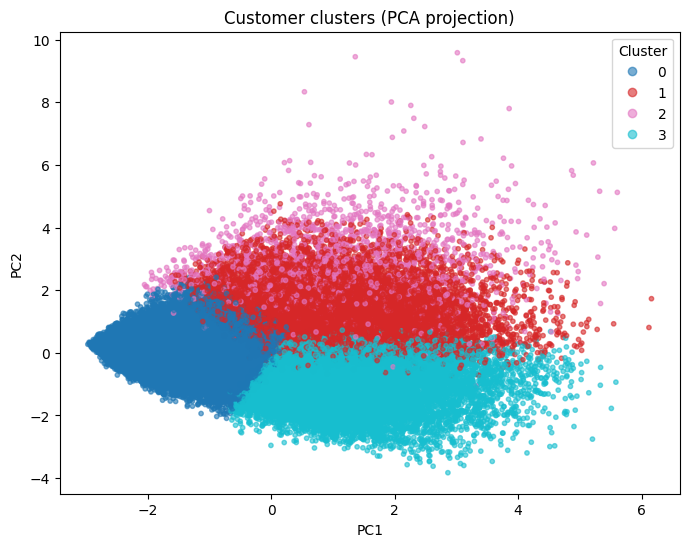

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=customers_clean["cluster"], cmap="tab10", s=10, alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer clusters (PCA projection)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()
